In [1]:
from pathlib import Path
import pandas as pd

In [2]:
base_dir = Path("/Users/shingzhan/Projects/sc2ts-paper")

In [3]:
csv_file = base_dir / "data" / "recombinants.csv"
df = pd.read_csv(csv_file)
df.head(2)

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,event_label,ripples_p4,ripples_p3,is_ripples_p4_recombinant,is_ripples_p3_recombinant
0,1280342,ERR9939974,1,1,1,695,958,1,COVID-ARTIC-V4.1,.,...,5,2,16,False,8,novel,False,False,False,False
1,663484,SRR20259474,1,1,1,510,1222,1,COVID-AMPLISEQ-V1,.,...,2,2,16,False,5,novel,False,True,False,True


In [4]:
import tskit
import tszip
ts_file = base_dir / "data" / "sc2ts_viridian_v1.2.trees.tsz"
ts = tszip.decompress(ts_file)

In [5]:
df = df[df.net_min_supporting_loci_lft_rgt_ge_4].reset_index(drop=True)
len(df)

354

In [6]:
# Let's first focus on the cases where both the parents are sample nodes.
parent_left_is_sample = ts.nodes_flags[df.parent_left.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
parent_right_is_sample = ts.nodes_flags[df.parent_right.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
df["parent_left_is_sample"] = parent_left_is_sample
df["parent_right_is_sample"] = parent_right_is_sample
df

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,event_label,ripples_p4,ripples_p3,is_ripples_p4_recombinant,is_ripples_p3_recombinant,parent_left_is_sample,parent_right_is_sample
0,1145912,ERR9380041,1,1,1,2833,3542,0,COVID-ARTIC-V4.1,4.1alt,...,47,True,5,novel,False,True,False,True,True,False
1,752005,ERR7480952,2,2,1,3402,4100,2,COVID-ARTIC-V4.1,4,...,15,True,7,novel,True,True,True,True,True,True
2,417645,SRR15776056,1,1,1,1878,4181,1,COVID-ARTIC-V3,.,...,29,True,5,novel,True,True,True,True,False,False
3,854204,SRR20186337,2,1,1,3123,4181,3,COVID-AMPLISEQ-V1,.,...,39,True,7,novel,True,True,True,True,True,True
4,1159411,ERR9444530,32,1,1,2833,4321,1,COVID-ARTIC-V4.1,4.1alt,...,48,True,5,XW,False,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,1406252,SRR22484659,2,1,1,27439,28312,2,COVID-ARTIC-V4.1,.,...,4,True,6,novel,False,False,False,False,False,True
350,1360479,SRR21636269,1,1,1,27439,28330,0,COVID-ARTIC-V4.1,.,...,4,True,5,novel,True,True,True,True,True,True
351,1274474,SRR21139593,21,1,1,27439,28330,0,COVID-ARTIC-V4.1,.,...,4,True,4,novel,False,False,False,False,False,False
352,330618,SRR17445276,2,1,1,28096,28697,1,COVID-ARTIC-V3,.,...,4,True,7,novel,True,True,True,True,False,False


In [7]:
sub_df = df[df.parent_left_is_sample & df.parent_right_is_sample].reset_index(drop=True)
sub_df

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,event_label,ripples_p4,ripples_p3,is_ripples_p4_recombinant,is_ripples_p3_recombinant,parent_left_is_sample,parent_right_is_sample
0,752005,ERR7480952,2,2,1,3402,4100,2,COVID-ARTIC-V4.1,4,...,15,True,7,novel,True,True,True,True,True,True
1,854204,SRR20186337,2,1,1,3123,4181,3,COVID-AMPLISEQ-V1,.,...,39,True,7,novel,True,True,True,True,True,True
2,1159411,ERR9444530,32,1,1,2833,4321,1,COVID-ARTIC-V4.1,4.1alt,...,48,True,5,XW,False,True,False,True,True,True
3,995727,ERR8495032,5,1,1,4185,4321,0,COVID-ARTIC-V4.1,4.1alt,...,44,True,6,novel,False,False,False,False,True,True
4,1058654,ERR8691075,154,1,1,4322,5386,0,COVID-ARTIC-V4.1,4.1alt,...,43,True,7,XQ,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,1348408,SRR21457722,1,1,1,25050,27438,1,COVID-ARTIC-V4.1,.,...,7,True,7,novel,True,True,True,True,True,True
124,419161,ERR6643654,2,1,1,17042,27656,1,COVID-ARTIC-V3,3,...,6,True,6,novel,False,True,False,True,True,True
125,1360676,SRR21637036,7,1,1,27789,27889,1,COVID-ARTIC-V4.1,.,...,5,True,6,novel,True,True,True,True,True,True
126,894321,SRR19223070,1,1,1,23127,28241,2,COVID-ARTIC-V4.1,.,...,5,True,6,novel,True,True,True,True,True,True


In [8]:
vir_df = pd.read_csv("../data/run_metadata.v05.tsv.gz", sep="\t")
vir_df.head(2)

/var/folders/4h/9ylb643n37d8jc7srjm7qzk00000gr/T/ipykernel_11957/252019682.py:1: DtypeWarning: Columns (18,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  vir_df = pd.read_csv("../data/run_metadata.v05.tsv.gz", sep="\t")


,In_may_2024_preprint,Study,Sample,Experiment,Run,Run_count,Platform,Country,Region,Collection_date,...,Genbank_N,Viridian_pangolin,Viridian_scorpio,Genbank_pangolin,Genbank_scorpio,Genbank_tree_name,Viridian_cons_len,Viridian_cons_het,Viridian_pangolin_1.29,Viridian_scorpio_1.29
0,T,PRJEB47121,SAMEA9781395,ERX6172603,ERR6546375,1,ILLUMINA,Estonia,none,2021-08-02,...,.,AY.100,Delta (B.1.617.2-like),.,.,.,29810,0,AY.100,Delta (B.1.617.2-like)
1,T,PRJEB47121,SAMEA9781396,ERX6172604,ERR6546376,1,ILLUMINA,Estonia,none,2021-08-02,...,.,AY.122,Delta (B.1.617.2-like),.,.,.,29807,3,AY.122,Delta (B.1.617.2-like)


In [9]:
parent_left_accessions = []
parent_left_countries = []
parent_left_regions = []
parent_right_accessions = []
parent_right_countries = []
parent_right_regions = []

for i, row in sub_df.iterrows():
    left_node = ts.node(id_=int(sub_df.parent_left[i]))
    right_node = ts.node(id_=int(sub_df.parent_right[i]))
    left_parent = left_node.metadata["sample_id"]
    left_country = vir_df.loc[vir_df["Run"] == left_parent, "Country"].iloc[0]
    left_region = vir_df.loc[vir_df["Run"] == left_parent, "Region"].iloc[0]
    if left_country == "United Kingdom":
        left_region = "UK"
    right_parent = right_node.metadata["sample_id"]
    right_country = vir_df.loc[vir_df["Run"] == right_parent, "Country"].iloc[0]
    right_region = vir_df.loc[vir_df["Run"] == right_parent, "Region"].iloc[0]
    if right_country == "United Kingdom":
        right_region = "UK"
    parent_left_accessions.append(left_parent)
    parent_left_countries.append(left_country)
    parent_left_regions.append(left_region)
    parent_right_accessions.append(right_parent)
    parent_right_countries.append(right_country)
    parent_right_regions.append(right_region)

assert len(parent_left_accessions) == len(sub_df)
assert len(parent_left_countries) == len(sub_df)
assert len(parent_left_regions) == len(sub_df)
assert len(parent_right_accessions) == len(sub_df)
assert len(parent_right_countries) == len(sub_df)
assert len(parent_right_regions) == len(sub_df)

In [10]:
sub_df["parent_time_diff"] = [round(x, 1) for x in abs(sub_df["parent_left_time"] - sub_df["parent_right_time"])]

sub_df["parent_left_accession"] = parent_left_accessions
sub_df["parent_left_country"] = parent_left_countries
sub_df["parent_left_region"] = parent_left_regions

sub_df["parent_right_accession"] = parent_right_accessions
sub_df["parent_right_country"] = parent_right_countries
sub_df["parent_right_region"] = parent_right_regions

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

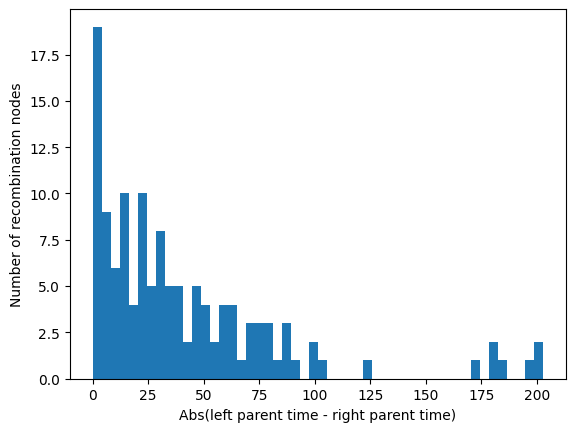

In [12]:
plt.hist(sub_df.parent_time_diff, bins=50)
plt.ylabel("Number of recombination nodes")
plt.xlabel("Abs(left parent time - right parent time)");

In [13]:
cofreq = pd.crosstab(sub_df["parent_left_country"], sub_df["parent_right_country"])
cofreq

parent_right_country,Estonia,India,Portugal,Slovakia,South Africa,USA,United Kingdom
parent_left_country,,,,,,,
Japan,0,0,0,0,0,0,1
Norway,0,0,0,0,0,0,1
Portugal,0,0,1,0,0,0,1
Slovakia,0,0,0,1,0,0,0
USA,0,2,2,1,1,50,13
United Kingdom,1,3,2,0,1,7,40


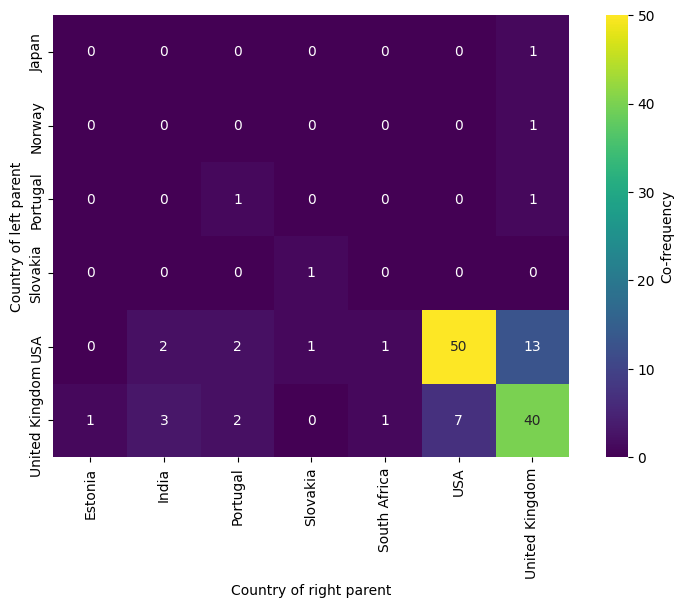

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cofreq,
    cmap="viridis",
    annot=True,
    square=True,
    cbar_kws={"label": "Co-frequency"}
)
plt.ylabel("Country of left parent")
plt.xlabel("Country of right parent")
plt.tight_layout()
plt.show()

In [15]:
cofreq = pd.crosstab(sub_df["parent_left_region"], sub_df["parent_right_region"])
cofreq

parent_right_region,"Ahmedabad, Gujarat","Anand, Gujarat",Arizona,Arkansas,California,Colorado,Eastern Cape,Illinois,Maryland,Massachusetts,...,South Dakota,"Surat, Gujarat",Texas,UK,Utah,"Vadodara, Gujarat",Washington,Western Cape,Wisconsin,none
parent_left_region,,,,,,,,,,,,,,,,,,,,,
California,0,0,0,0,2,1,0,0,0,0,...,0,0,0,2,0,0,0,0,0,1
Colorado,0,0,0,0,0,2,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
Florida,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
Georgia,0,0,0,0,1,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
Illinois,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Indiana,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Kentucky,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Louisiana,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Maryland,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


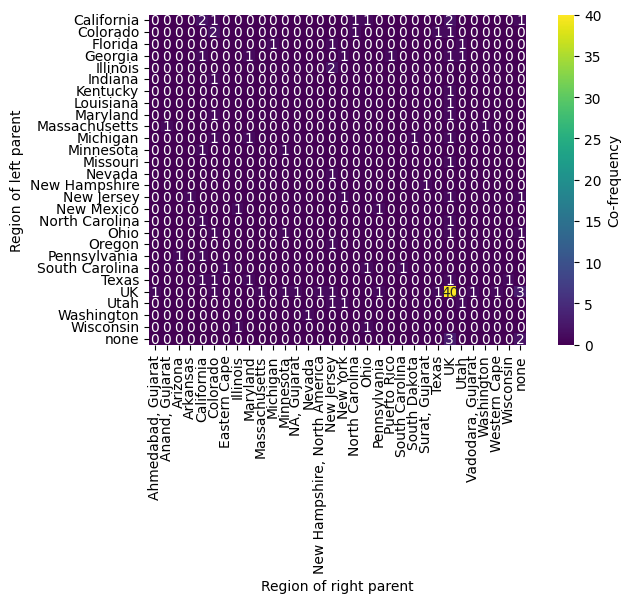

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cofreq,
    cmap="viridis",
    annot=True,
    square=True,
    cbar_kws={"label": "Co-frequency"}
)
plt.ylabel("Region of left parent")
plt.xlabel("Region of right parent")
plt.tight_layout()
plt.show()

In [17]:
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 200)
sub_df[
    [
        "sample_id",
        "num_descendant_samples",
        #"parent_left_time",
        #"parent_right_time",
        "parent_time_diff",
        "parent_left",
        "parent_right",
        #"parent_left_accession",
        #"parent_right_accession",
        "parent_left_country",
        "parent_right_country",
        "parent_left_region",
        "parent_right_region",
    ]
].sort_values("parent_time_diff", ascending=False)

,sample_id,num_descendant_samples,parent_time_diff,parent_left,parent_right,parent_left_country,parent_right_country,parent_left_region,parent_right_region
32,SRR21605320,2,203.0,1036988,1355933,United Kingdom,India,UK,"Ahmedabad, Gujarat"
122,ERR10666854,1,202.0,1402812,1200476,USA,Portugal,New Jersey,none
6,ERR8076129,16,198.0,303923,940265,United Kingdom,United Kingdom,UK,UK
119,DRR321268,5,186.0,269371,57543,Japan,United Kingdom,none,UK
27,ERR4825079,1,180.0,2576,32404,United Kingdom,United Kingdom,UK,UK
101,ERR9858123,2,179.0,1252294,843172,United Kingdom,India,UK,"NA, Gujarat"
85,ERR10749002,1,171.0,1271313,1413538,United Kingdom,United Kingdom,UK,UK
52,ERR10427736,1,122.0,1377891,1247397,United Kingdom,South Africa,UK,Western Cape
103,SRR21001321,1,104.0,1168743,1290333,USA,United Kingdom,Maryland,UK
29,ERR7471772,8,99.0,321733,636109,United Kingdom,United Kingdom,UK,UK


In [18]:
import numpy as np
import numba


@numba.njit
def get_descendants(
    focal_node_id: int,
    max_time_increment: float,  # days
    nodes_time: np.ndarray,
    edges_parent: np.ndarray,
    edges_child: np.ndarray,
) -> np.ndarray:
    focal_node_time = nodes_time[focal_node_id]
    min_age = focal_node_time - max_time_increment
    visited = []
    stack = [focal_node_id]
    while len(stack) > 0:
        u = stack.pop(0)
        if nodes_time[u] < min_age:
            continue
        visited.append(u)
        for v in edges_child[edges_parent == u]:
            stack.append(v)
    return np.asarray(visited, dtype=np.int32)

In [19]:
def get_geo_composition(
    focal_node_id: int,
    max_time_increment: float,
    ts: tskit.TreeSequence,
    df: pd.DataFrame,
) -> list:
    countries = []
    desc_nodes = get_descendants(
        focal_node_id,
        max_time_increment=max_time_increment,
        nodes_time=ts.nodes_time,
        edges_child=ts.edges_child,
        edges_parent=ts.edges_parent,
    )
    for u in desc_nodes:
        if ts.nodes_flags[u] != tskit.NODE_IS_SAMPLE:
            continue
        node = ts.node(id_=u)
        sample_id = node.metadata["sample_id"]
        sample_country = df[df["Run"] == sample_id]["Country"].str[:].iloc[0]
        countries.append(sample_country)
    return countries

In [20]:
from collections import Counter
from tqdm import tqdm


MAX_TIME_INC = 28

geo_comps = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    comp_left = Counter(
        get_geo_composition(
            focal_node_id=row.parent_left,
            max_time_increment=MAX_TIME_INC,
            ts=ts,
            df=vir_df,
        )
    )
    comp_right = Counter(
        get_geo_composition(
            focal_node_id=row.parent_right,
            max_time_increment=MAX_TIME_INC,
            ts=ts,
            df=vir_df,
        )
    )
    geo_comps.append(
        {
            "recombinant": row.recombinant,
            "parent_left_is_sample": row.parent_left_is_sample,
            "parent_right_is_sample": row.parent_right_is_sample,
            "parent_left_geo_comp": str(dict(comp_left)),
            "parent_right_geo_comp": str(dict(comp_right)),
        }
    )
geo_comps_df = pd.DataFrame(geo_comps)

100%|██████████| 354/354 [14:24<00:00,  2.44s/it]


In [21]:
geo_comps_df[
    np.logical_and(
        geo_comps_df.parent_left_is_sample,
        geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,752005,True,True,{'United Kingdom': 3},{'United Kingdom': 10}
1,854204,True,True,{'USA': 24},{'USA': 62}
2,1159411,True,True,{'United Kingdom': 6},{'United Kingdom': 2}
3,995727,True,True,{'United Kingdom': 5},{'United Kingdom': 12}
4,1058654,True,True,{'United Kingdom': 1},"{'United Kingdom': 10, 'USA': 1}"
5,496620,True,True,{'USA': 2},{'USA': 2}
6,946761,True,True,{'United Kingdom': 1},{'United Kingdom': 8}
7,803762,True,True,{'United Kingdom': 4},{'USA': 4}
8,540037,True,True,{'United Kingdom': 11},{'United Kingdom': 23}
9,967112,True,True,{'USA': 2},{'United Kingdom': 1}


In [22]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_or(
        ~geo_comps_df.parent_left_is_sample,
        ~geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,1145912,True,False,{'Mauritius': 1},{'United Kingdom': 2}
1,417645,False,False,{},{}
2,1404808,False,False,{'USA': 2},"{'United Kingdom': 1, 'Angola': 1}"
3,334514,False,True,{'USA': 5},{'USA': 26}
4,1110637,False,False,{'United Kingdom': 2},{'United Kingdom': 1}
5,550957,False,True,{'United Kingdom': 2},{'United Kingdom': 5}
6,876195,False,True,{'USA': 2},{'USA': 1}
7,1057278,False,False,{},{}
8,130133,True,False,{'United Kingdom': 4},{}
9,380339,False,True,{},{'USA': 19}


In [23]:
MAX_TIME_INC = 56

geo_comps = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    comp_left = Counter(
        get_geo_composition(
            focal_node_id=row.parent_left,
            max_time_increment=MAX_TIME_INC,
            ts=ts,
            df=vir_df,
        )
    )
    comp_right = Counter(
        get_geo_composition(
            focal_node_id=row.parent_right,
            max_time_increment=MAX_TIME_INC,
            ts=ts,
            df=vir_df,
        )
    )
    geo_comps.append(
        {
            "recombinant": row.recombinant,
            "parent_left_is_sample": row.parent_left_is_sample,
            "parent_right_is_sample": row.parent_right_is_sample,
            "parent_left_geo_comp": str(dict(comp_left)),
            "parent_right_geo_comp": str(dict(comp_right)),
        }
    )
geo_comps_df = pd.DataFrame(geo_comps)

100%|██████████| 354/354 [1:11:59<00:00, 12.20s/it] 


In [24]:
geo_comps_df[
    np.logical_and(
        geo_comps_df.parent_left_is_sample,
        geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,752005,True,True,{'United Kingdom': 5},{'United Kingdom': 29}
1,854204,True,True,{'USA': 57},{'USA': 178}
2,1159411,True,True,{'United Kingdom': 6},"{'United Kingdom': 6, 'USA': 2}"
3,995727,True,True,{'United Kingdom': 6},{'United Kingdom': 16}
4,1058654,True,True,{'United Kingdom': 2},"{'United Kingdom': 35, 'USA': 8, 'Slovakia': 2}"
5,496620,True,True,{'USA': 2},{'USA': 8}
6,946761,True,True,{'United Kingdom': 1},{'United Kingdom': 9}
7,803762,True,True,{'United Kingdom': 4},{'USA': 4}
8,540037,True,True,{'United Kingdom': 30},{'United Kingdom': 82}
9,967112,True,True,{'USA': 2},"{'United Kingdom': 1, 'USA': 1}"


In [26]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_and(
        geo_comps_df.parent_left_is_sample,
        ~geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,1145912,True,False,"{'Mauritius': 1, 'United Kingdom': 1}",{'United Kingdom': 6}
1,130133,True,False,{'United Kingdom': 21},{'United Kingdom': 4}
2,1410844,True,False,{'United Kingdom': 1},"{'USA': 10, 'United Kingdom': 1}"
3,369130,True,False,"{'USA': 2, 'United Kingdom': 8, 'Slovakia': 4}",{'Netherlands': 5}
4,1083412,True,False,"{'USA': 2, 'United Kingdom': 3}","{'United Kingdom': 11, 'Portugal': 48, 'USA': 4}"
5,396951,True,False,{'United Kingdom': 4},{'Slovakia': 1}
6,1034619,True,False,{'United Kingdom': 6},"{'South Africa': 3, 'Norway': 6, 'United Kingd..."
7,1338501,True,False,{'United Kingdom': 1},{'USA': 5}
8,1172823,True,False,"{'United Kingdom': 77, 'USA': 3}",{'USA': 2}
9,28379,True,False,{'USA': 8},{'USA': 23}


In [27]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_and(
        ~geo_comps_df.parent_left_is_sample,
        geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,334514,False,True,{'USA': 52},{'USA': 47}
1,550957,False,True,{'United Kingdom': 23},{'United Kingdom': 7}
2,876195,False,True,{'USA': 3},{'USA': 2}
3,380339,False,True,{},{'USA': 64}
4,1053479,False,True,{'USA': 1},"{'USA': 408, 'United Kingdom': 29}"
5,1106336,False,True,"{'United Kingdom': 5, 'USA': 1}",{'United Kingdom': 2}
6,82697,False,True,{'United Kingdom': 8},{'United Kingdom': 2}
7,1095230,False,True,"{'United Kingdom': 5, 'USA': 1}",{'United Kingdom': 5}
8,465910,False,True,{},"{'United Kingdom': 329, 'Slovakia': 2, 'Portug..."
9,1000242,False,True,{'USA': 3},{'USA': 7}


In [28]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_and(
        ~geo_comps_df.parent_left_is_sample,
        ~geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,417645,False,False,{},{'USA': 3}
1,1404808,False,False,{'USA': 2},"{'USA': 20, 'United Kingdom': 2, 'Slovakia': 2..."
2,1110637,False,False,{'United Kingdom': 8},{'United Kingdom': 5}
3,1057278,False,False,{'USA': 2},"{'USA': 2, 'United Kingdom': 2}"
4,1113544,False,False,"{'United Kingdom': 9, 'Slovakia': 1}",{'United Kingdom': 49}
5,1200360,False,False,{'United Kingdom': 2},{'United Kingdom': 2}
6,1407336,False,False,{},{}
7,37970,False,False,{'United Kingdom': 24},{'United Kingdom': 86}
8,405949,False,False,{'USA': 52},{'USA': 47}
9,503891,False,False,{},{}
